### loan approval prediction using logistic regression

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
df=pd.read_csv('Loan_Train.csv')

In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.shape

(614, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


### Data cleaning and preprocessing

In [7]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
df['Dependents']=df['Dependents'].replace('3+',3)
df['Dependents']=pd.to_numeric(df['Dependents'],errors='coerce')

In [9]:
#filling missing value
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])
df['Married']=df['Married'].fillna(df['Married'].mode()[0])
df['Dependents']=df['Dependents'].fillna(df['Dependents'].median())
df['Self_Employed']=df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount']=df['LoanAmount'].fillna(df['LoanAmount'].mode()[0])
df['Loan_Amount_Term']=df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History']=df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [10]:
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [11]:
# Feature enginerring
df['Total_Income']=df['ApplicantIncome']+df['CoapplicantIncome']


In [12]:
df.drop('Loan_ID',axis=1,inplace=True)

In [13]:
#encoding categorical variables
cat_cols=['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status']

le=LabelEncoder()
for col in cat_cols:
    df[col]=le.fit_transform(df[col])


In [14]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,1,0,0.0,0,0,5849,0.0,120.0,360.0,1.0,2,1,5849.0
1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0
2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0
3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0
4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0


In [15]:
#train test split
X=df.drop('Loan_Status',axis=1)
y=df['Loan_Status']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


### logistic model assumption checking

In [16]:
#binary outcome variable and checking the balance of data
print("value counts for dependent variable 'y':")
print(y.value_counts())

value counts for dependent variable 'y':
Loan_Status
1    422
0    192
Name: count, dtype: int64


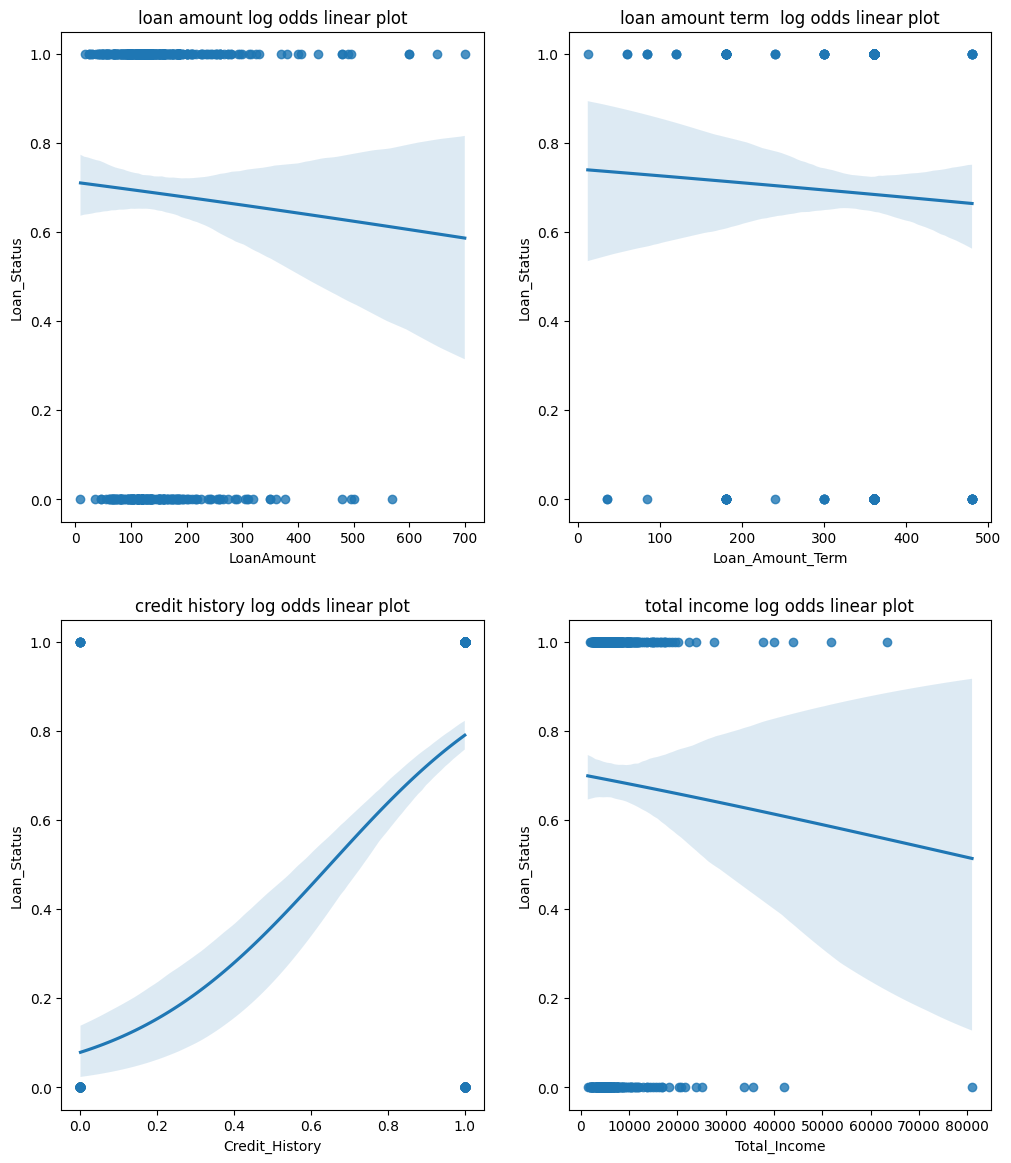

In [17]:
#checking linearity of independent variables with log odds
cont_variables=['LoanAmount','Loan_Amount_Term', 'Credit_History','Total_Income']
fig,ax=plt.subplots(2,2,figsize=(12,14))
sns.regplot(data=df,x=cont_variables[0],y='Loan_Status',ax=ax[0,0],logistic=True).set_title('loan amount log odds linear plot');
sns.regplot(data=df,x=cont_variables[1],y='Loan_Status',ax=ax[0,1],logistic=True).set_title('loan amount term  log odds linear plot');
sns.regplot(data=df,x=cont_variables[2],y='Loan_Status',ax=ax[1,0],logistic=True).set_title('credit history log odds linear plot');   
sns.regplot(data=df,x=cont_variables[3],y='Loan_Status',ax=ax[1,1],logistic=True).set_title('total income log odds linear plot');

In [18]:
#checking multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
def vif(X):
    vif=pd.DataFrame()
    vif['feature']=X.columns
    vif['VIF']=[variance_inflation_factor(X.values,i)for i in range(len(X.columns))]
    print(vif)
vif(X)

              feature        VIF
0              Gender   6.002051
1             Married   3.654179
2          Dependents   1.792095
3           Education   1.306879
4       Self_Employed   1.176596
5     ApplicantIncome        inf
6   CoapplicantIncome        inf
7          LoanAmount   6.772218
8    Loan_Amount_Term  10.310045
9      Credit_History   6.058999
10      Property_Area   2.574327
11       Total_Income        inf


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [19]:
X.drop(['Total_Income','ApplicantIncome','CoapplicantIncome','Loan_Amount_Term'],axis=1,inplace=True)
vif(X)

          feature       VIF
0          Gender  5.394707
1         Married  3.637844
2      Dependents  1.786528
3       Education  1.267353
4   Self_Employed  1.168675
5      LoanAmount  3.689536
6  Credit_History  4.434434
7   Property_Area  2.394021


#### balancing the data using SMOTE

In [20]:
from imblearn.over_sampling import SMOTE
smote =SMOTE()
X_resampled,y_resampled= smote.fit_resample(X,y)

In [21]:
print(y_resampled.value_counts())

Loan_Status
1    422
0    422
Name: count, dtype: int64


In [22]:
X_train,X_test,y_train,y_test=train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42,stratify=y_resampled)

In [23]:
from sklearn.linear_model import LogisticRegression as lg
model= lg(max_iter=200)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve
roc_auc=roc_auc_score(y_test,model.predict_proba(X_test)[:,1])
print(f'ROC AUC SCORE:{roc_auc}')

ROC AUC SCORE:0.8465686274509804


In [26]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.85      0.61      0.71        85
           1       0.69      0.89      0.78        84

    accuracy                           0.75       169
   macro avg       0.77      0.75      0.75       169
weighted avg       0.77      0.75      0.75       169

[[52 33]
 [ 9 75]]


#### Roc AUC curve

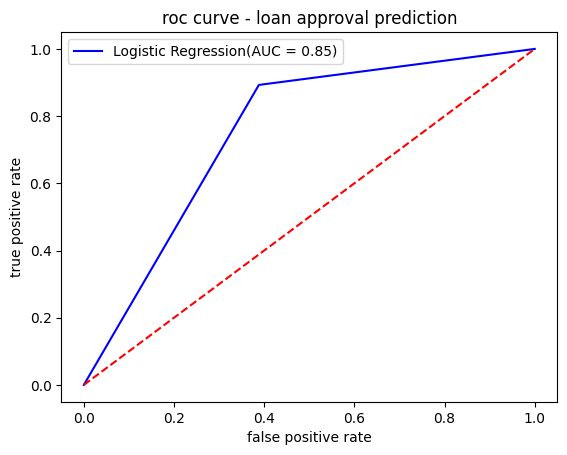

In [27]:
fpr,tpr,thresholds= roc_curve(y_test,y_pred)
plt.plot(fpr,tpr,color='blue',label=f'Logistic Regression(AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],color='red',linestyle='--')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('roc curve - loan approval prediction')
plt.legend();

### feature importance

In [28]:
feature_imp=pd.DataFrame({'Feature':X.columns,'coefficients':model.coef_[0]}).sort_values(by='coefficients',ascending=False)
print(feature_imp)

          Feature  coefficients
6  Credit_History      3.710857
1         Married      0.885697
7   Property_Area      0.354944
4   Self_Employed      0.299881
0          Gender      0.124039
3       Education      0.019923
5      LoanAmount     -0.001674
2      Dependents     -0.073556


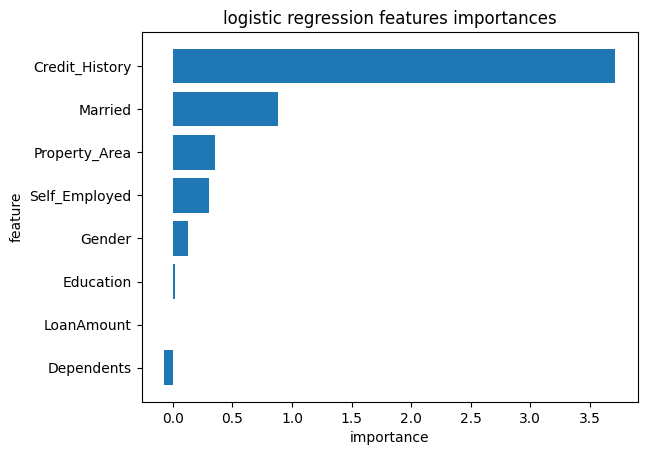

In [29]:
plt.barh(feature_imp['Feature'],feature_imp['coefficients'])
plt.xlabel('importance')
plt.ylabel('feature')
plt.title('logistic regression features importances')
plt.gca().invert_yaxis();

In [30]:
import pickle
pickle.dump(model,open('model.pkl','wb'))
pickle.dump(le,open('le.pkl','wb'))